In [15]:
#!pip install plotnine

In [22]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from plotnine import ggplot, aes, geom_point, facet_grid, labs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [16]:
# read in data
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [10]:
data.isna().sum()

months              0
act0                0
act1                0
CPUE                0
biomass             0
cluster_act0    43758
cluster_act1    43758
dtype: int64

In [3]:
# remove anomolous biomass data
data = data[(data['biomass'] != -1) & (data['biomass'] <= -0.2)]

In [4]:
data_july = data[data['months'] == 7].drop(columns=['months'])

In [65]:
data_july.head()

,act0,act1,CPUE,biomass
13,0.812212,0.881972,-0.953593,-0.904733
22,-0.609525,0.120705,-0.973870,-0.798833
31,0.822527,0.857075,-0.961020,-0.832061
40,-0.964028,-0.718855,-0.978160,-0.723350
49,-0.935469,-0.819039,-0.986494,-0.782305


In [25]:
kmeans_july_act0 = KMeans(n_clusters=4).fit(data_july.drop(columns=['act1']))
kmeans_july_act1 = KMeans(n_clusters=4).fit(data_july.drop(columns=['act0']))

In [5]:
scores = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init = 30).fit(data_july.drop(columns=['act1']))
    scores.append(silhouette_score(data_july.drop(columns=['act1']), km.labels_))

# get k means with highest silhouette score
kmeans_july_act0 = KMeans(n_clusters=K_range[np.argmax(scores)]).fit(data_july.drop(columns=['act1']))


In [6]:
scores

[0.9390436952411602,
 0.9123902577659534,
 0.7636053320819413,
 0.7547092698502296,
 0.6766356784184313,
 0.7119217363606447,
 0.7130221749325845,
 0.7063048175973182]

In [7]:
# add label data to dataframe
data_july['cluster_act0'] = kmeans_july_act0.labels_
#data_july['cluster_act1'] = kmeans_july_act1.labels_

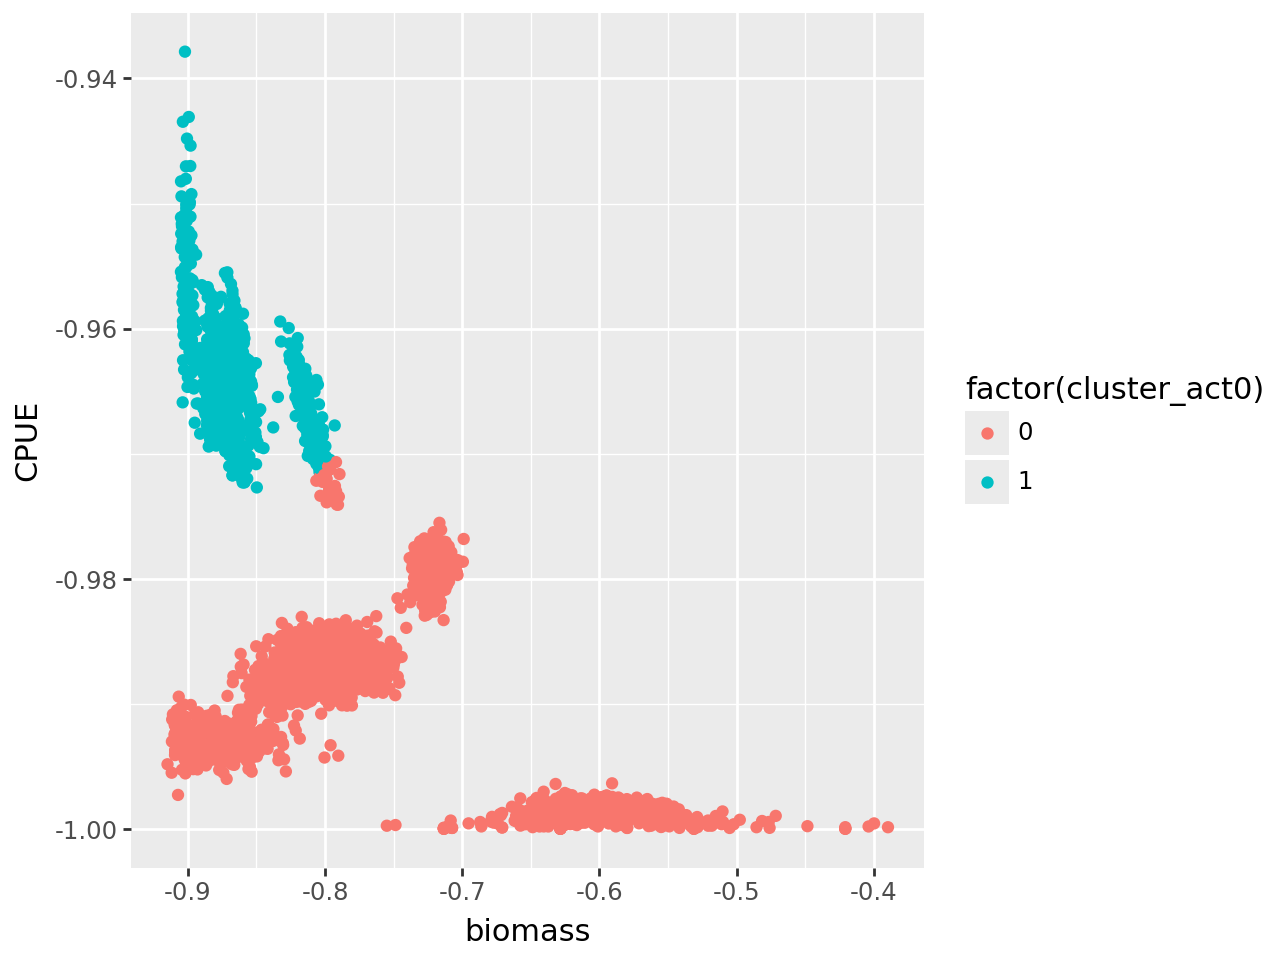

In [8]:
(
    ggplot(data_july, aes(x='biomass', y='CPUE', color='factor(cluster_act0)')) +
    geom_point()
)

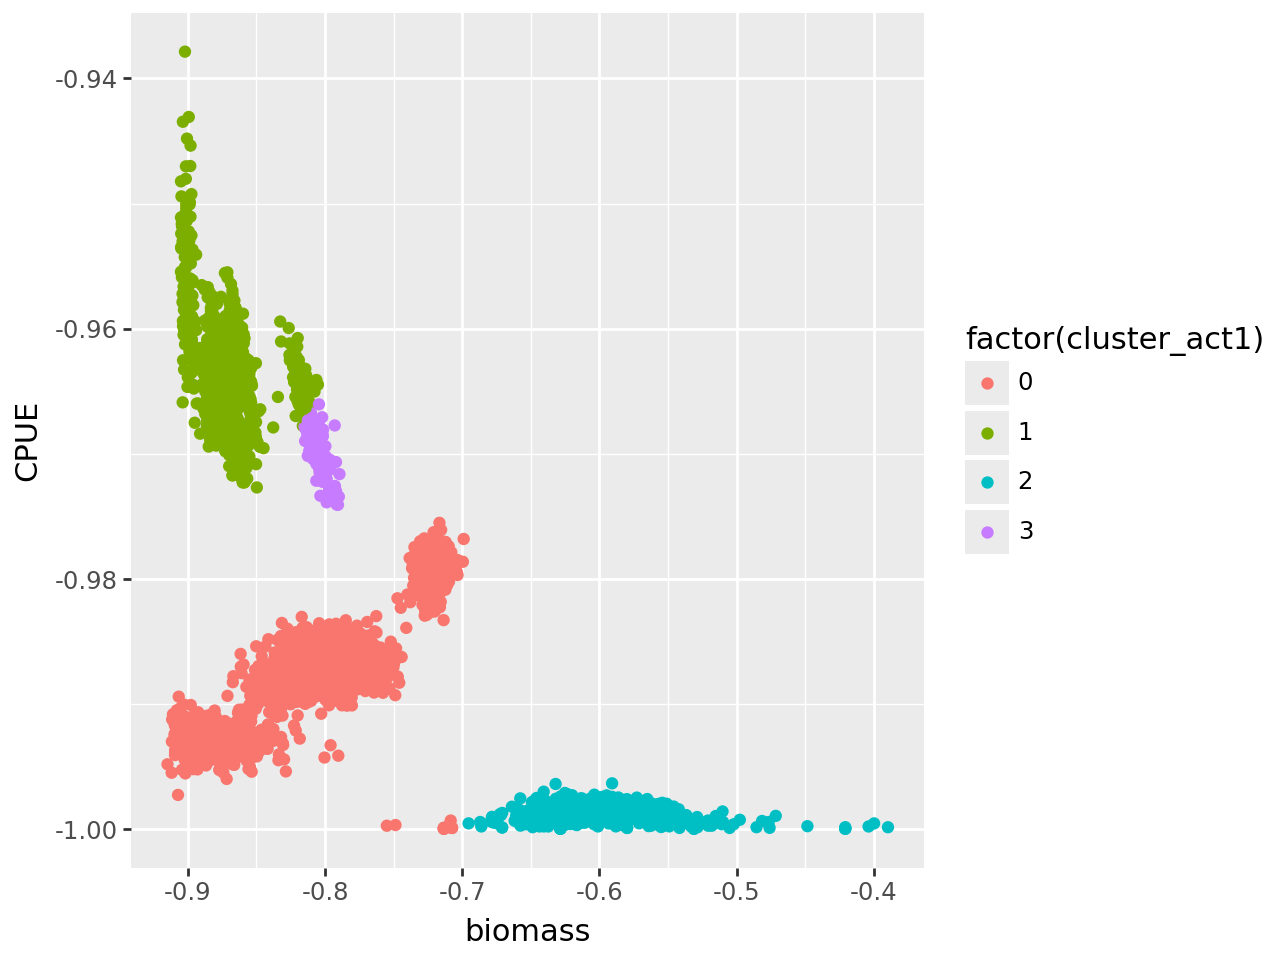

In [28]:
(
    ggplot(data_july, aes(x='biomass', y='CPUE', color='factor(cluster_act1)')) +
    geom_point()
)

In [11]:
centroids = np.array([data_july[kmeans.labels_ == i].mean(axis=0) for i in range(4)])

In [12]:
centroids

array([[-0.93659871, -0.81425695, -0.98608746, -0.79378964],
       [ 0.83393577,  0.84128615, -0.96343975, -0.87146855],
       [ 0.10573912,  0.40916842, -0.97003962, -0.80476606],
       [-0.8757469 , -0.82739507, -0.99866226, -0.59517049]])

In [25]:
# set K range and loop through months and actions to find best k and cluster data
K_range = range(2, 7)
months = data['months'].unique()
actions = ['act0', 'act1']
all_centroids = []
all_labeled = []

for month in months:
    data_month = data[data['months'] == month].drop(columns=['months'])
    
    for action in actions:
        other_action = 'act1' if action == 'act0' else 'act0'
        X = data_month.drop(columns=[other_action])
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        scores = []
        for k in K_range:
            km = KMeans(n_clusters=k, n_init=30, random_state=42).fit(X_scaled)
            scores.append(silhouette_score(X_scaled, km.labels_))
        
        best_k = K_range[np.argmax(scores)]
        kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=42).fit(X_scaled)
        
        # build labeled chunk
        chunk = X.copy().reset_index(drop=True)
        chunk['month'] = month
        chunk['action'] = action
        chunk['cluster'] = kmeans.labels_
        all_labeled.append(chunk)
        
        # store centroids
        centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
        centroids_df = pd.DataFrame(centroids_original, columns=X.columns)
        centroids_df['month'] = month
        centroids_df['action'] = action
        centroids_df['cluster'] = range(best_k)
        all_centroids.append(centroids_df)

labeled = pd.concat(all_labeled, ignore_index=True)
centroids = pd.concat(all_centroids, ignore_index=True)



In [19]:
labeled.head()

,act0,CPUE,biomass,month,action,cluster,act1
0,-0.911334,-1.000000,-1.000000,3,act0,0,NaN
1,-0.911334,-1.000000,-1.000000,3,act0,0,NaN
2,-0.964028,-0.961698,-0.828590,3,act0,0,NaN
3,-0.964028,-0.968981,-0.788381,3,act0,0,NaN
4,-0.964028,-0.962088,-0.811697,3,act0,0,NaN


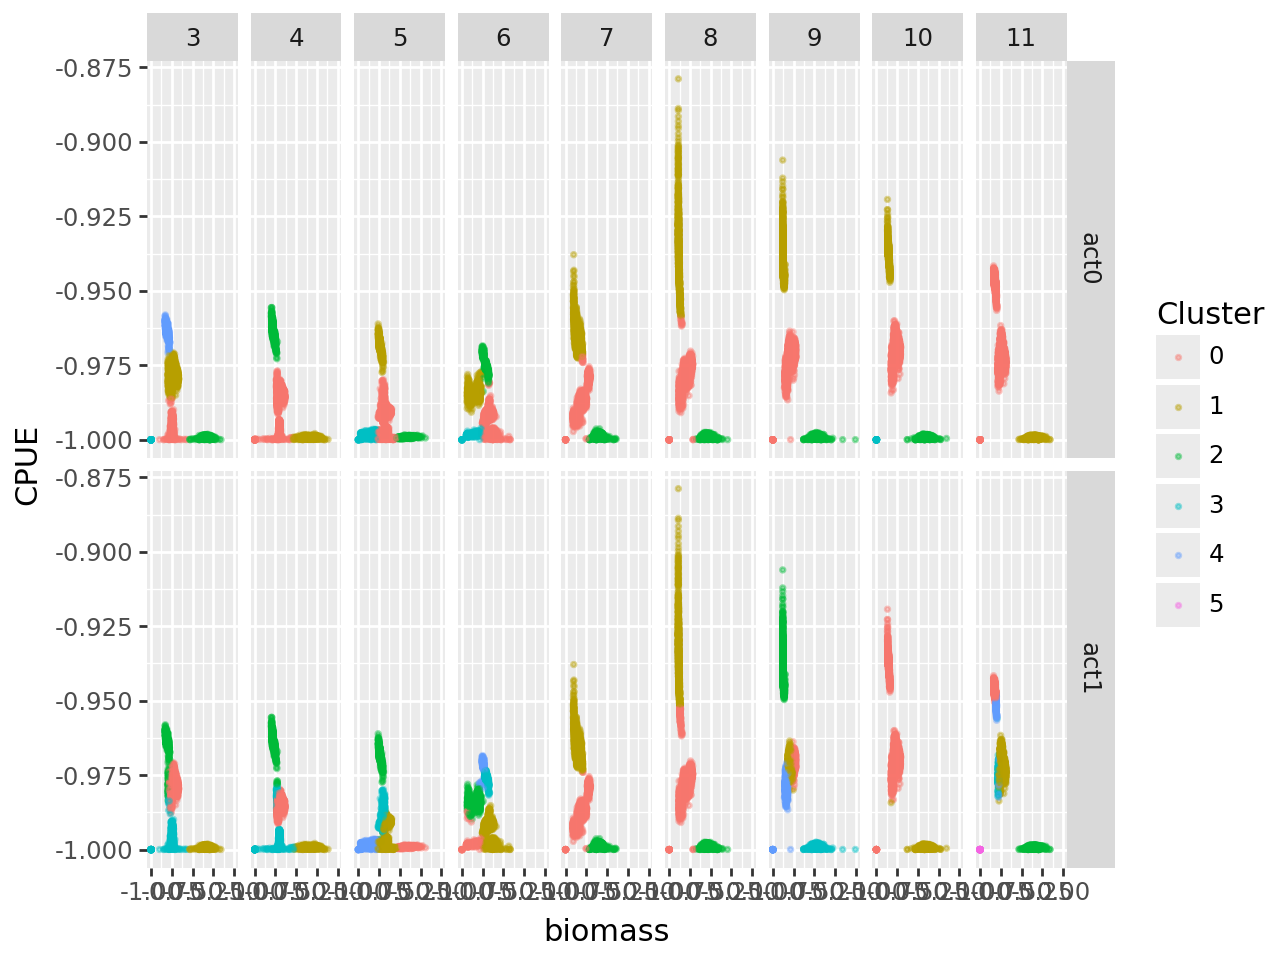

In [26]:
(
    ggplot(labeled, aes(x='biomass', y='CPUE', color='factor(cluster)'))
    + geom_point(alpha=0.4, size=0.5)
    + facet_grid('action ~ month')
    + labs(color='Cluster')
)